# IoT MQTT Authentication — Logistic Regression Pipeline

A complete **data-mining pipeline** (CRISP-DM style) for authentication-anomaly
detection on the simulator's output:

1. Data loading  2. Data understanding (EDA)  3. Data cleaning
4. Preprocessing  5. Model training (Logistic Regression)  6. Evaluation
7. Leakage-aware sanity check  8. Multiclass extension  9. Summary

The dataset is the current (Phase C) simulator output — 9 attack variants, the
six-phase authentication lifecycle, and 109 per-session features.
Logistic Regression is the first (linear, interpretable) baseline.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 130)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Loading

Load the per-session feature table produced by the simulator.

In [2]:
def find_features_csv():
    names = ["iot_auth_ml_features.csv", "iot_auth_dataset_features.csv"]
    bases = [Path.cwd(), *Path.cwd().parents]
    for base in bases:
        for sub in ["simulator/data/output", "IoT_auth_simulator/simulator/data/output"]:
            for n in names:
                p = base / sub / n
                if p.exists():
                    return p
    raise FileNotFoundError("Could not locate a *_features.csv under simulator/data/output/")

DATA_PATH = find_features_csv()
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape :", df.shape)
df.head(3)

Loaded: C:\Users\lamia\Desktop\simulator_bis\PFE_simulator\IoT_auth_simulator\simulator\data\output\iot_auth_ml_features.csv
Shape : (3100, 109)


,scenario_id,session_id,device_id,gateway_id,claimed_device_id,source_ip,registered_device,source_connection_count,battery_level,tcp_flags,connection_duration,tcp_rtt,packet_rate,inter_arrival_time,frame_length,tcp_segment_len,pairing_result,pairing_latency_ms,mqtt_msg_type,connect_flags,clean_session,username_present,password_length,keep_alive,mqtt_version,connack_code,auth_result,auth_latency_ms,failed_auth_count,requested_topic,topic_length,operation,authorization_result,topic_scope_violation,retain_flag,message_id,duplicate_flag,payload_length,payload_hash,qos_level,message_rate,byte_rate,trust_score,re_auth_required,session_present,source_ip_change,replay_window_violation,s1_latency_ms,s2_latency_ms,s3_latency_ms,s4_latency_ms,s5_latency_ms,s6_latency_ms,session_duration_s,mean_delay_s,max_delay_s,min_delay_s,n_events,n_discovery,n_gateway_advertisement,n_pairing_request,n_pairing_response,n_enrollment_request,n_enrollment_confirmed,n_registration_request,n_registration_confirmed,n_authentication_request,n_challenge_sent,n_nonce_received,n_response_sent,n_authentication_success,n_authentication_failure,n_token_issued,n_token_presented,n_token_validated,n_token_rejected,n_renewal_request,n_token_expired,n_session_opened,n_session_closed,n_access_request,n_access_granted,n_access_denied,n_retry,n_timeout,n_disconnect,visited_states,reached_session_open,reached_access_granted,reached_authenticated,n_failures,n_retries,failure_rate,n_token_reuses,n_nonce_reuses,identity_mismatch,n_state_jumps,is_anomaly,attack_type,attack_phase,severity,token_age_at_replay,nonce_age_at_reuse,timestamp_delta_s,duplicate_session_count,identity_claim_mismatch,token_device_mismatch,unauthorized_access_attempt,steps_before_access
0,755eaaba-95c5-4b64-ac6c-c7dfc914956c,2c67673d-0692-4591-895b-e72eeb17a544,aa71cb41-b6f7-461d-b100-ff4177f4f81c,e064048c,victim-27cddd9c,10.0.1.194,0,5,49.1,"SYN,ACK",247.80,67.66,8.792,113.74,139,442,1,68.26,PUBLISH,0,0,0,0,10,5,pending,0,0.00,0,iot/aa71cb41/telemetry,22,publish,0,0,0,46768,0,1185,303f2a17ba68efd7433bbaa0c832d374509f1f0c4f6604...,2,2.196,2602.26,0.421,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0.0,0.2478,0.0354,0.0684,0.0166,7,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,6,0,0,1,1,0,0.1429,0,0,1,1,1,identity_token_mismatch,session_opened,high,0.0,0.0,0.0,0,1,1,0,0
1,b85ec32c-983b-449a-9e57-c92693ac5104,12655e4d-390b-450a-9eb4-aaf0152362cc,a7732c33-c2e2-47cf-bb1a-e9eaa4c28219,71c2a68f,a7732c33-c2e2-47cf-bb1a-e9eaa4c28219,10.0.1.154,1,9,42.9,"SYN,ACK",33337.04,21.66,2.806,356.38,185,198,1,224.80,DISCONNECT,0,0,0,0,120,5,success,1,25.93,0,iot/a7732c33/telemetry,22,pub_sub,1,0,0,9266,0,0,NaN,1,1.150,118.45,0.795,0,1,0,0,0.0,53.88,25.93,59.31,59.52,0.0,33.3370,1.6669,27.6000,0.0259,20,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,1,0,0,16,1,1,1,1,0,0.0500,6,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0
2,7b572db1-0e3c-4faa-9de8-e1eb45dbec3b,0d900228-0871-4809-9088-62e9b777dad8,d4f99e6f-a911-42ee-afec-391fdf08a47f,8e16b0ca,d4f99e6f-a911-42ee-afec-391fdf08a47f,10.0.1.62,1,10,51.2,"SYN,ACK",64086.73,18.95,7.079,141.26,201,154,1,283.94,PUBLISH,0,0,0,0,60,5,success,1,38.05,0,iot/d4f99e6f/telemetry,22,publish,1,1,0,58039,0,457,16eba2e8502223fd60168fcc7310282562afb0cb808166...,2,4.828,2206.40,0.807,0,1,0,0,0.0,53.14,38.05,68.80,59.90,0.0,64.0867,2.6703,50.2685,0.0380,24,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,3,3,1,1,0,0,16,1,1,1,1,0,0.0417,10,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0


## 2. Data Understanding (EDA)

In [3]:
print("Rows x Cols:", df.shape)
print("\nDtype counts:")
print(df.dtypes.value_counts())

print("\nBinary target — is_anomaly (proportion):")
print(df["is_anomaly"].value_counts(normalize=True).round(3).rename({0: "normal", 1: "anomaly"}))

print("\nMulticlass target — attack_type (counts):")
print(df["attack_type"].value_counts())

Rows x Cols: (3100, 109)

Dtype counts:
int64      70
float64    24
str        15
Name: count, dtype: int64

Binary target — is_anomaly (proportion):
is_anomaly
normal     0.645
anomaly    0.355
Name: proportion, dtype: float64

Multiclass target — attack_type (counts):
attack_type
normal                     2000
identity_token_mismatch     132
nonce_reuse                 132
access_without_auth         132
replay_token                132
impersonation               132
timestamp_inconsistency     132
duplicate_sequence          121
abnormal_failure_rate        99
abnormal_renewal             88
Name: count, dtype: int64


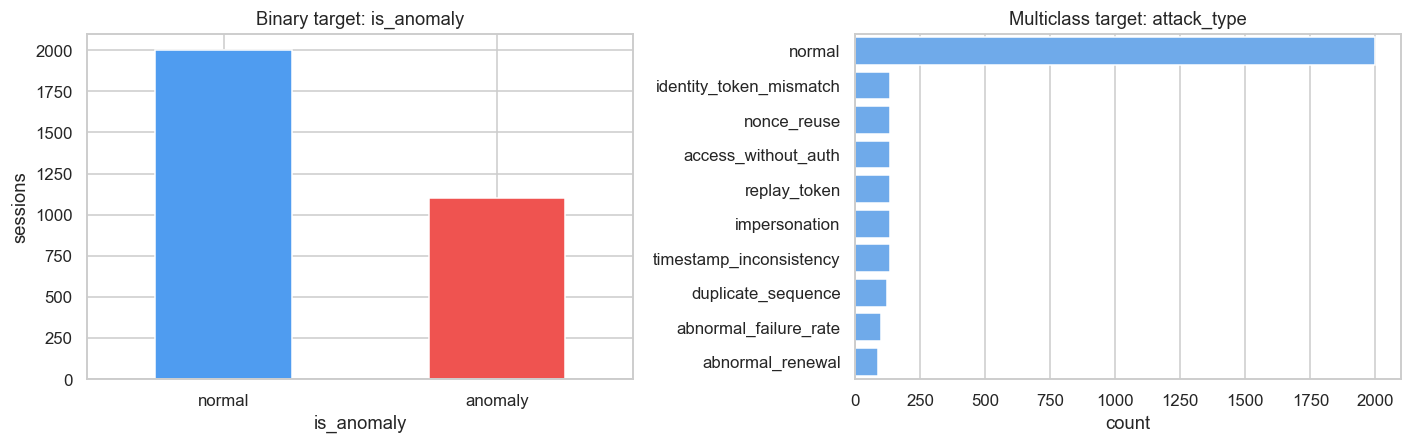

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
(df["is_anomaly"].map({0: "normal", 1: "anomaly"}).value_counts()
   .plot.bar(ax=axes[0], color=["#4f9cf0", "#ef5350"], rot=0))
axes[0].set_title("Binary target: is_anomaly"); axes[0].set_ylabel("sessions")

order = df["attack_type"].value_counts().index
sns.countplot(data=df, y="attack_type", order=order, ax=axes[1], color="#5aa9ff")
axes[1].set_title("Multiclass target: attack_type"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

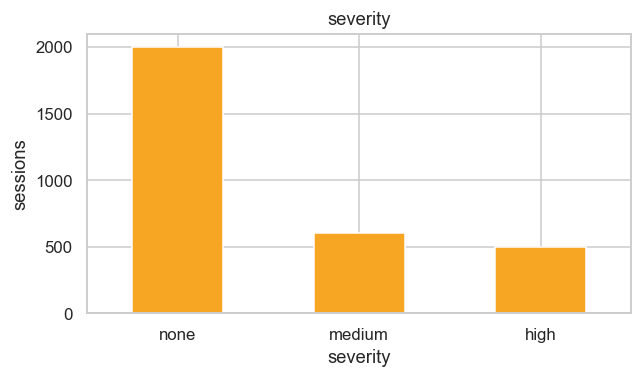

In [5]:
# Severity distribution (and attacker_class if the dataset carries it)
present = [c for c in ["severity", "attacker_class"] if c in df.columns]
palette = {"severity": "#f6a623", "attacker_class": "#37c66f"}
fig, axes = plt.subplots(1, len(present), figsize=(6 * len(present), 3.6), squeeze=False)
for ax, col in zip(axes[0], present):
    df[col].value_counts().plot.bar(ax=ax, color=palette[col], rot=0)
    ax.set_title(col); ax.set_ylabel("sessions")
plt.tight_layout(); plt.show()

In [6]:
# Missingness
miss = df.isna().mean().sort_values(ascending=False)
print("Columns with any missing values:", int((miss > 0).sum()))
miss[miss > 0].head(15)

Columns with any missing values: 1


payload_hash    0.68
dtype: float64

### Leakage peek

Attacks that terminate the session at the injection point are **structurally
shorter** than normal sessions, so session-length / lifecycle-completion
features correlate strongly with the label. This is a documented property of
the synthetic dataset — we visualise it here and address it in Section 7.

C:\Users\lamia\AppData\Local\Temp\ipykernel_3876\1838266520.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["normal", "anomaly"]); axes[0].set_title("n_events by class")
C:\Users\lamia\AppData\Local\Temp\ipykernel_3876\1838266520.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["normal", "anomaly"]); axes[1].set_title("session_duration_s by class")


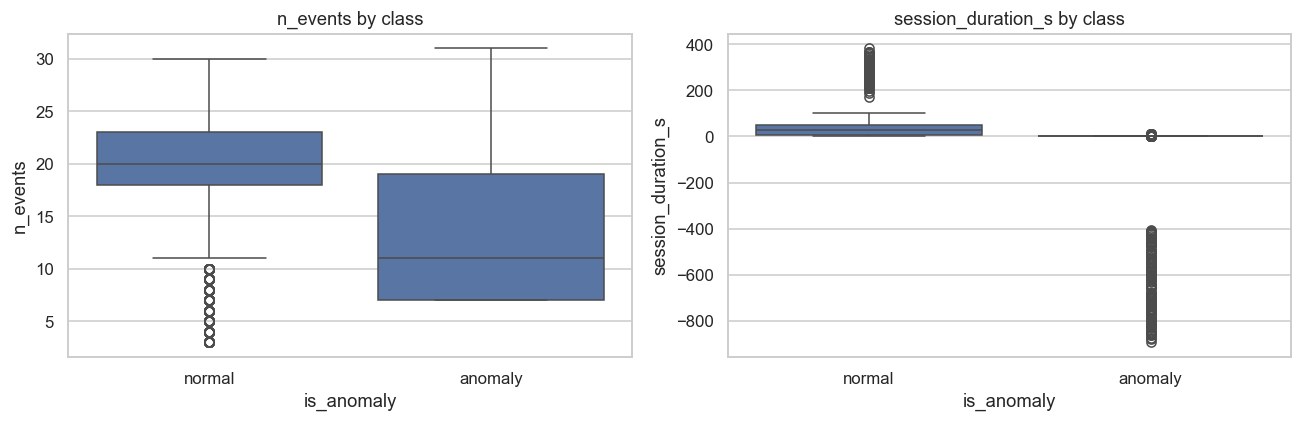

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="is_anomaly", y="n_events", ax=axes[0])
axes[0].set_xticklabels(["normal", "anomaly"]); axes[0].set_title("n_events by class")
sns.boxplot(data=df, x="is_anomaly", y="session_duration_s", ax=axes[1])
axes[1].set_xticklabels(["normal", "anomaly"]); axes[1].set_title("session_duration_s by class")
plt.tight_layout(); plt.show()

## 3. Data Cleaning

We remove three groups of columns:

* **Identifiers** — UUIDs / IPs / topics with no predictive value and infinite cardinality.
* **Label aliases** — `attack_type`, `attack_phase`, `severity` (and
  `attacker_class` when present) all encode the target and would leak it directly.
* **Constant columns** — zero-variance features (e.g. event counts for events
  that never fire in a nominal flow) carry no information.

Missing values are then imputed (`0` for numerics, `"missing"` for categoricals).

In [8]:
TARGET = "is_anomaly"

ID_COLS = ["scenario_id", "session_id", "device_id", "gateway_id",
           "claimed_device_id", "source_ip", "requested_topic",
           "payload_hash", "message_id"]
LABEL_ALIASES = ["attack_type", "attack_phase", "severity", "attacker_class"]

const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns dropped (", len(const_cols), "):", const_cols)

drop_cols = sorted((set(ID_COLS) | set(LABEL_ALIASES) | set(const_cols)) & set(df.columns))
X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
X[cat_cols] = X[cat_cols].fillna("missing")
X[num_cols] = X[num_cols].fillna(0)

print(f"\nFeatures kept: {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print("Categorical:", cat_cols)

Constant columns dropped ( 11 ): ['mqtt_version', 'topic_length', 'duplicate_flag', 's1_latency_ms', 'n_gateway_advertisement', 'n_pairing_request', 'n_registration_request', 'n_registration_confirmed', 'n_token_rejected', 'n_token_expired', 'n_timeout']

Features kept: 85  (81 numeric, 4 categorical)
Categorical: ['tcp_flags', 'mqtt_msg_type', 'connack_code', 'operation']


C:\Users\lamia\AppData\Local\Temp\ipykernel_3876\2590703816.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## 4. Preprocessing & Train/Test Split

* Numeric features → `StandardScaler` (LR is sensitive to feature scale).
* Categorical features → one-hot encoding (`handle_unknown='ignore'`).
* Stratified 80/20 split to preserve the class ratio.

All preprocessing lives inside a `Pipeline`, so it is fit on the **train fold only**
and there is no leakage from the test fold.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.bincount(y_train))

Train: (2480, 85)  Test: (620, 85)
Train class balance: [1600  880]


## 5. Model Training — Logistic Regression

`class_weight='balanced'` compensates for the class imbalance;
`max_iter=2000` ensures convergence on the one-hot expanded space.

In [10]:
lr_clf = Pipeline([
    ("pre", preprocess),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced",
                              random_state=RANDOM_STATE)),
])
lr_clf.fit(X_train, y_train)
print("Fitted. Total engineered features:",
      lr_clf.named_steps["pre"].transform(X_train[:1]).shape[1])

Fitted. Total engineered features: 102


## 6. Evaluation

In [11]:
y_pred  = lr_clf.predict(X_test)
y_proba = lr_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"], digits=4))
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("F1 (weighted):", round(f1_score(y_test, y_pred, average="weighted"), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000       400
     anomaly     1.0000    1.0000    1.0000       220

    accuracy                         1.0000       620
   macro avg     1.0000    1.0000    1.0000       620
weighted avg     1.0000    1.0000    1.0000       620

Accuracy : 1.0
F1 (weighted): 1.0
ROC-AUC  : 1.0


C:\Users\lamia\Desktop\simulator_bis\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


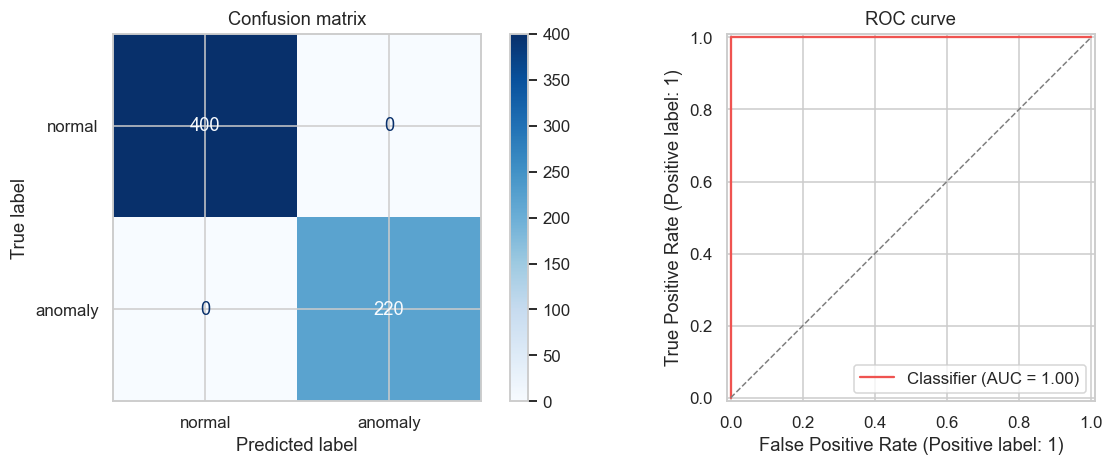

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["normal", "anomaly"], cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#ef5350")
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve")
plt.tight_layout(); plt.show()

### Model interpretation — Logistic Regression coefficients

Because LR is linear, its coefficients are directly readable: a large positive
coefficient pushes a session toward *anomaly*, a large negative one toward *normal*.

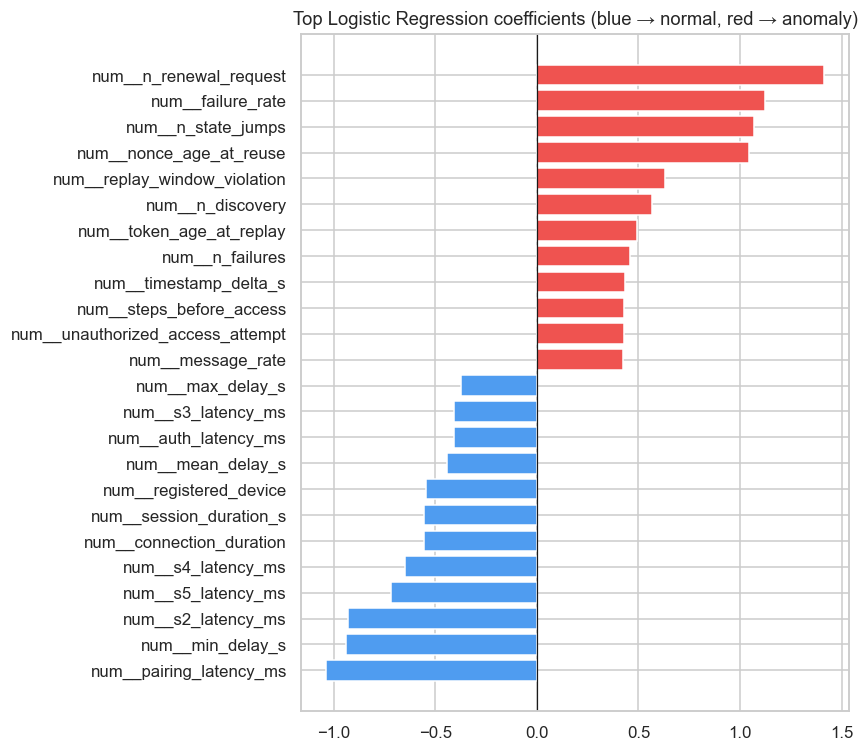

In [13]:
feat_names = lr_clf.named_steps["pre"].get_feature_names_out()
coefs = lr_clf.named_steps["lr"].coef_[0]
coef_df = (pd.DataFrame({"feature": feat_names, "coef": coefs})
             .assign(abs=lambda d: d["coef"].abs())
             .sort_values("coef"))

top = pd.concat([coef_df.head(12), coef_df.tail(12)])
plt.figure(figsize=(8, 7))
colors = ["#4f9cf0" if c < 0 else "#ef5350" for c in top["coef"]]
plt.barh(top["feature"], top["coef"], color=colors)
plt.axvline(0, color="k", lw=0.8)
plt.title("Top Logistic Regression coefficients (blue → normal, red → anomaly)")
plt.tight_layout(); plt.show()

## 7. Leakage-aware sanity check

The scores above are inflated by **structural leakage**: because several attack
families truncate the session at the injection point, session-length and
lifecycle-completion features (`n_events`, `session_duration_s`,
`reached_*`, `visited_states`, …) separate the classes almost perfectly on
their own — independently of any authentication signal.

Here we retrain LR **after dropping that structural group**, keeping only the
semantic authentication features (token freshness, nonce reuse, identity
mismatch, per-anomaly signals, network/MQTT context). Scores should drop toward
a more honest estimate; they remain high because the *intended* per-anomaly
signals (which a real detector should use) are still present.

In [14]:
STRUCTURAL_LEAK = [
    "n_events", "session_duration_s", "mean_delay_s", "max_delay_s", "min_delay_s",
    "visited_states", "reached_session_open", "reached_access_granted",
    "reached_authenticated", "n_state_jumps", "connection_duration",
] + [c for c in num_cols if c.startswith("n_") and c not in
     ("n_failures", "n_retries", "n_nonce_reuses", "n_token_reuses", "n_renewal_request")]

leak_drop = [c for c in STRUCTURAL_LEAK if c in X.columns]
X2 = X.drop(columns=leak_drop)
num2 = [c for c in num_cols if c in X2.columns]
cat2 = [c for c in cat_cols if c in X2.columns]

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
pre2 = ColumnTransformer([
    ("num", StandardScaler(), num2),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat2),
])
lr2 = Pipeline([("pre", pre2),
                ("lr", LogisticRegression(max_iter=2000, class_weight="balanced",
                                          random_state=RANDOM_STATE))]).fit(Xtr2, ytr2)
p2 = lr2.predict(Xte2); pr2 = lr2.predict_proba(Xte2)[:, 1]

print(f"Dropped {len(leak_drop)} structural-leakage features.")
print("\n              full features   leakage-hardened")
print(f"Accuracy   :     {accuracy_score(y_test, y_pred):.4f}          {accuracy_score(yte2, p2):.4f}")
print(f"F1 weighted:     {f1_score(y_test, y_pred, average='weighted'):.4f}          {f1_score(yte2, p2, average='weighted'):.4f}")
print(f"ROC-AUC    :     {roc_auc_score(y_test, y_proba):.4f}          {roc_auc_score(yte2, pr2):.4f}")

Dropped 33 structural-leakage features.

              full features   leakage-hardened
Accuracy   :     1.0000          0.9984
F1 weighted:     1.0000          0.9984
ROC-AUC    :     1.0000          1.0000


## 8. Multiclass extension — `attack_type`

The same pipeline, now predicting the specific attack variant (9 attacks +
`normal`). Multinomial Logistic Regression, one-vs-rest ROC-AUC (macro).

In [15]:
ymc = df["attack_type"]
Xmc = df.drop(columns=[c for c in (ID_COLS + ["attack_type", "attack_phase",
              "severity", "attacker_class", "is_anomaly"] + const_cols) if c in df.columns])
cmc = Xmc.select_dtypes(include="object").columns.tolist()
nmc = Xmc.select_dtypes(exclude="object").columns.tolist()
Xmc[cmc] = Xmc[cmc].fillna("missing"); Xmc[nmc] = Xmc[nmc].fillna(0)

Xtr, Xte, ytr, yte = train_test_split(
    Xmc, ymc, test_size=0.20, stratify=ymc, random_state=RANDOM_STATE)
pre_mc = ColumnTransformer([
    ("num", StandardScaler(), nmc),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cmc),
])
lr_mc = Pipeline([("pre", pre_mc),
                  ("lr", LogisticRegression(max_iter=3000, class_weight="balanced",
                                            random_state=RANDOM_STATE))]).fit(Xtr, ytr)
pmc = lr_mc.predict(Xte)
proba_mc = lr_mc.predict_proba(Xte)

print(classification_report(yte, pmc, digits=3))
print("Macro one-vs-rest ROC-AUC:",
      round(roc_auc_score(yte, proba_mc, multi_class="ovr", average="macro",
                          labels=lr_mc.classes_), 4))

C:\Users\lamia\AppData\Local\Temp\ipykernel_3876\2491024948.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cmc = Xmc.select_dtypes(include="object").columns.tolist()


                         precision    recall  f1-score   support

  abnormal_failure_rate      1.000     1.000     1.000        20
       abnormal_renewal      1.000     1.000     1.000        18
    access_without_auth      1.000     1.000     1.000        26
     duplicate_sequence      1.000     1.000     1.000        24
identity_token_mismatch      1.000     1.000     1.000        26
          impersonation      1.000     1.000     1.000        26
            nonce_reuse      1.000     1.000     1.000        27
                 normal      1.000     1.000     1.000       400
           replay_token      1.000     1.000     1.000        27
timestamp_inconsistency      1.000     1.000     1.000        26

               accuracy                          1.000       620
              macro avg      1.000     1.000     1.000       620
           weighted avg      1.000     1.000     1.000       620

Macro one-vs-rest ROC-AUC: 1.0


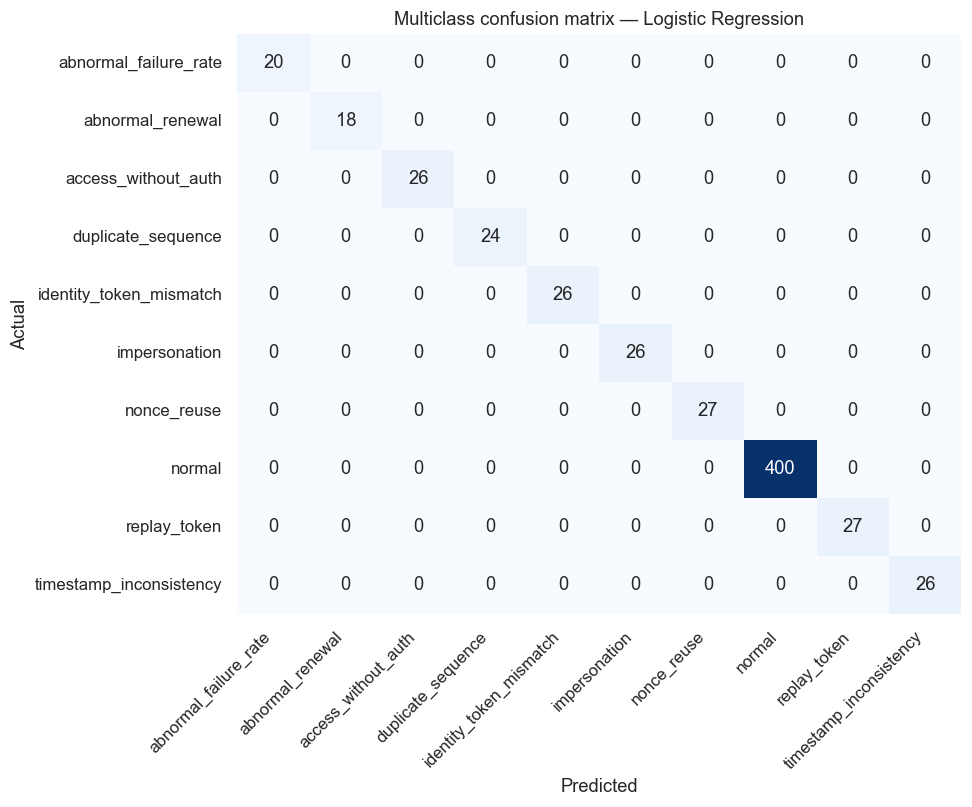

In [16]:
cm = confusion_matrix(yte, pmc, labels=lr_mc.classes_)
plt.figure(figsize=(9, 7.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_mc.classes_, yticklabels=lr_mc.classes_, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Multiclass confusion matrix — Logistic Regression")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 9. Summary

* **Pipeline:** load → EDA → clean (drop identifiers, label aliases, constant
  columns) → scale + one-hot inside a leak-free `Pipeline` → stratified split →
  Logistic Regression.
* **Binary detection** (`is_anomaly`) and **multiclass detection**
  (`attack_type`) are both solved at high accuracy by the linear model.
* **Caveat — label leakage:** part of that performance comes from structural
  session-length differences, not authentication behaviour. Section 7 quantifies
  this by retraining without the structural group; the leakage-hardened scores
  are the more honest estimate, and they stay high because the *intended*
  per-anomaly signals remain.
* **Next models:** Decision Tree and Random Forest (non-linear baselines) for
  comparison against this linear reference, using the identical cleaning and
  split so results are directly comparable.